In [1]:
# for n columns (n+1) coefficient

In [2]:
from sklearn.datasets import make_regression
import pandas as pd
import numpy as np

import plotly.express as px
import plotly.graph_objects as go

from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

In [3]:
X,y = make_regression(n_samples=100, n_features=2, n_informative=2, n_targets=1, noise=50)

In [4]:
df = pd.DataFrame({'feature1':X[:,0],'feature2':X[:,1],'target':y})

In [5]:
df.shape

(100, 3)

In [6]:
df.head()

,feature1,feature2,target
0,0.851332,1.640683,272.940889
1,0.903049,-0.900312,-40.893726
2,-1.194881,0.360732,-50.209151
3,1.130693,0.169456,65.559340
4,-0.849148,1.269709,55.528382


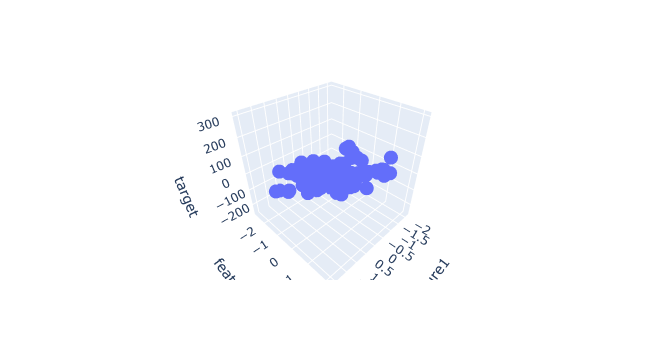

In [7]:
fig = px.scatter_3d(df, x='feature1', y='feature2', z='target')

fig.show()

In [8]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=3)

In [9]:
from sklearn.linear_model import LinearRegression

In [10]:
lr = LinearRegression()

In [11]:
lr.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [12]:
y_pred = lr.predict(X_test)

In [13]:
print("MAE",mean_absolute_error(y_test,y_pred))
print("MSE",mean_squared_error(y_test,y_pred))
print("R2 score",r2_score(y_test,y_pred))

MAE 46.93214432688736
MSE 2848.3976308121264
R2 score 0.8499855968452847


In [16]:
x = np.linspace(-5, 5, 10)
y = np.linspace(-5, 5, 10)
xGrid, yGrid = np.meshgrid(y, x)

final = np.vstack((xGrid.ravel().reshape(1,100),yGrid.ravel().reshape(1,100))).T
z_final = lr.predict(final).reshape(10,10)
z = z_final

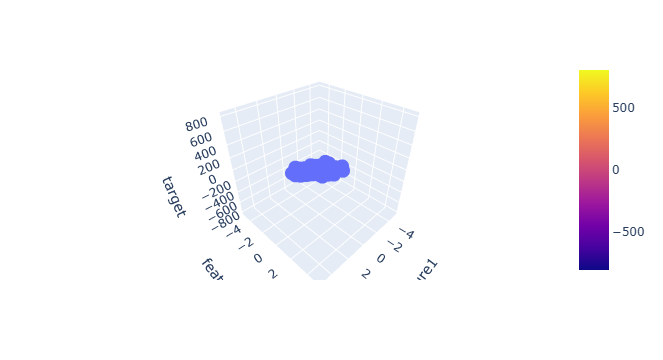

In [17]:
fig = px.scatter_3d(df, x='feature1', y='feature2', z='target')

fig.add_trace(go.Surface(x = x, y = y, z =z ))

fig.show()